In [28]:
import csv
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def csv2dict(csv_file_path):
    result_dict = {}

    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)

        # Assuming the first row contains keys and the second row contains values
        keys = next(csv_reader)
        values = next(csv_reader)

        # Create a dictionary
        result_dict = {key: int(value) for key, value in zip(keys, values)}
    
    return result_dict

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
    
        # Write the header
        csv_writer.writerow(my_dict.keys())
    
        # Write the data
        csv_writer.writerow(my_dict.values())

# All domains/xgroups in E. coli genome (RS_GCF_011881725.1)

In [3]:
# d = csv2dict('ecoli_domain2freq.csv')
# x = csv2dict('ecoli_xgroup2freq.csv')
# print(len(d))
# print(len(x))

In [4]:
# print(d)

# Protein secondary structure annotation

In [5]:
path = '/Users/longolab/Desktop/JPred_API_client_v_1_5/protein.faa'

length = []
seq = ''
with open(path, 'r') as file:
    output = file.readlines()
    for line in output:
        if line.startswith('>'):
            length.append(len(seq))
            seq = ''  # reset
        else:
            seq += line.strip()
length.pop(0)  # remove first
length.append(26)  # append last
print(len(length))

4723


In [6]:
print(length)

[325, 246, 62, 302, 369, 94, 317, 129, 87, 60, 404, 395, 646, 456, 313, 62, 397, 74, 424, 97, 60, 371, 1261, 409, 318, 725, 75, 66, 344, 63, 102, 60, 65, 704, 103, 68, 89, 88, 150, 86, 196, 85, 111, 626, 282, 93, 89, 43, 277, 37, 86, 133, 70, 186, 248, 1756, 717, 71, 941, 458, 120, 181, 94, 115, 247, 85, 602, 212, 330, 210, 128, 875, 73, 171, 83, 76, 196, 475, 188, 103, 121, 229, 127, 298, 95, 53, 239, 652, 77, 210, 78, 139, 64, 187, 453, 76, 85, 39, 60, 153, 100, 323, 70, 191, 323, 388, 63, 500, 149, 159, 64, 220, 733, 425, 580, 315, 574, 397, 126, 90, 285, 285, 275, 304, 63, 98, 87, 413, 24, 243, 165, 223, 131, 763, 513, 248, 645, 344, 590, 284, 357, 247, 169, 67, 93, 165, 141, 141, 57, 155, 150, 211, 115, 302, 176, 909, 175, 280, 125, 396, 172, 91, 815, 159, 387, 93, 453, 404, 238, 702, 201, 110, 240, 467, 401, 1025, 1040, 415, 219, 253, 646, 450, 282, 1105, 213, 193, 617, 96, 112, 527, 379, 147, 720, 279, 162, 405, 406, 248, 182, 373, 321, 159, 407, 478, 456, 464, 492, 426, 406, 46

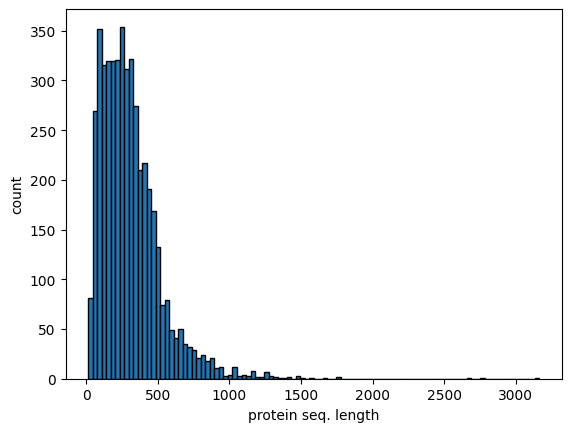

In [7]:
plt.hist(length, bins=100, edgecolor='k')
plt.xlabel('protein seq. length')
plt.ylabel('count')
# plt.savefig('seq_len_full.png')
plt.show()

In [8]:
tooShort = [item for item in length if item < 20]
print(len(tooShort))
tooLong = [item for item in length if item > 800]
print(len(tooLong))

11
154


In [9]:
# I need to pre-process the protein.faa file because Jpred does not parse newline \n between sequences ... CURSED

In [10]:
# with open('/Users/longolab/Desktop/JPred_API_client_v_1_5/protein.faa', 'r') as file:
#     fasta_lines = file.readlines()

# # Initialize variables to store sequence information
# sequence_lines = []
# current_sequence = ''

# # Process each line of the FASTA file
# for line in fasta_lines:
#     if line.startswith('>'):
#         # Append the previous sequence to the list of sequence lines
#         if current_sequence:
#             sequence_lines.append(current_sequence)
#         # Append the header line to the list of sequence lines
#         sequence_lines.append(line.strip())
#         # Start a new sequence
#         current_sequence = ''
#     else:
#         # Remove newline characters and append the line to the current sequence
#         current_sequence += line.strip()

# # Append the last sequence
# sequence_lines.append(current_sequence)

# # Write the modified sequences to a new FASTA file
# with open('modified_file.faa', 'w') as output_file:
#     for line in sequence_lines:
#         output_file.write(line + '\n')

In [11]:
def find_pattern(s):
    
    # Rule 2: Replace 3 or more 'H's with 'A'
    s = re.sub(r'H{3,}', 'A', s)

    # Rule 3: Replace 3 or more 'E's with 'B'
    s = re.sub(r'E{3,}', 'B', s)
    
    # Rule 4: remove the rest of Es and Hs
    s = re.sub(r'E|H', '', s)
    
    # Rule 5: change AB back to HE
    s = re.sub(r'A', 'H', s)
    s = re.sub(r'B', 'E', s)
    
    return s

# Test cases
patterns = [
    'HHHHHH',
    'EEEEEE',
    'EEEEEEHHHHHHH',
    'HHHHHHHEEEEEE',
    'HHHHHHHEEEEEEHHHHHHHHH',
    'HHHHHHHEEEEEEHHHHHHHHHEH',  # extra EH at the end
    'HHHHHLEEEE'  # contains L
]
for pattern in patterns:
    print(find_pattern(pattern))

H
E
EH
HE
HEH
HEH
HLE


In [12]:
def process_string(s):
    result = ''

    # Rule 1: If the pattern alternates between 'H' and 'E', 2 or more times, replace with '-'
    s = re.sub(r'(EH){2,}|(HE){2,}', '-', s)
    
    s = re.sub(r'(?<!-)-(?!-)', '', s)  # Remove single '-'
    s = re.sub(r'(?<!-)--(?!-)', '', s)  # Remove consecutive '--'

    streak = ''
    for index, char in enumerate(s):
        if char != '-':  # => add to streak
            streak += char
        elif char == '-':  # got interrupted by '-'
            if len(streak) >= 3:
                # streak is long enough, record the pattern
                new = find_pattern(streak)
                if new != '':
                    result += new
                    result += '-'
                streak = ''
            else:
                # streak too short
                streak = ''
    
    # Check if it's the last character that's E or H
    if index == len(s) - 1 and char != '-':
        if len(streak) >= 3:
            # streak is long enough, record the pattern
            result += find_pattern(streak)
    
    # add '-' to beginning if 3 or more '-' present:
    if s[:3] == '---':
        result = '-' + result
    return result
 

patterns = ['-----EEEE------HHHHHH--------------------HH-----------EEEEE---',
            '-----EEEE-HHHHHH-----HHHHHHEHEHEEEEE-----------HH--EEEEE---',
            'EEEE-HHHHHH-----HHHHHHEHEHEEEEE-----------HH--EEEEE---',
            '---EEEE-HHHHHH-----HHHHHHEHEHEEEEE-----------HH--EEEEE',
            '-----HHH---EEEEEEEE------EHHHHHHHHHH-----HHHHHHHHHHHHHHHH----HEHH--------EHHHHHHHHHHHHHHHHHE--'
           ]
for pattern in patterns:
    print(process_string(pattern))

-E-H-E-
-EH-HE-E-
EH-HE-E-
-EH-HE-E
-H-E-H-H-H


## Parsing Jpred output

In [13]:
prot2sec_reduced = {}
prot2sec = {}

In [14]:
jpbatch_path = '/Users/longolab/Desktop/JPred_API_client_v_1_5/proteome_ecoli.faa_dir_output'
for file_name in os.listdir(jpbatch_path):
    if file_name.endswith('.jnet'):
        prot_name = file_name[:10]
        output_path = os.path.join(jpbatch_path, file_name)
        
        with open(output_path, 'r') as file:
            output = file.readlines()
            for line in output:
                if line.startswith('jnetpred:'):
                    string = ''.join(line[9:].split(',')[:-1])  # remove 'jnetpred:' and '\n', connect the strings
                    prot2sec[prot_name] = string
                    prot2sec_reduced[prot_name] = process_string(string)
                    
                    # print(prot_name)
                    # print(string)
                    # print(process_string(string))
                    # print('===============')

In [15]:
print(len(prot2sec_reduced))
print(len(prot2sec))

4557
4557


In [16]:
prot2sec_reduced

{'AYO74062.1': '-H-H-E-E-E-EH-E-E',
 'AYO72500.1': '-H-E-E-E-E-E-E-E-E-E-E-E-E-E-E-E-',
 'AYO74375.1': 'H-H-H-E-E-H-H-H-H-H-',
 'AYO75144.1': '-H-E-E-H-E-H-H-H-H-',
 'AYO72982.1': 'E-E-H-E-E-H-E-E-E',
 'AYO72435.1': 'E-E-E-E-H-E-H-EH-E-H-H-E-H-E-H-',
 'AYO72090.1': '-H-H-E-H-E-H-H-E-H-E-H-E-H-H-H-H-',
 'AYO75321.1': 'H-H-H-H-H-H-H-H-H-H-H-',
 'AYO75312.1': 'E-H-E-E-H-E-H-E-H-E-H-E-EH-E-H-E-H-H-H-H-',
 'AYO71735.1': '-H-H-H-H-H-H-',
 'AYO72648.1': '-H-E-E-',
 'AYO75076.1': 'H-H-E-H-H-H-E-H-E-E-',
 'AYO72046.1': 'E-E-H-E-E-H-H-H-H-H-H-EHE-E-H-E-E-E-H-E-E-H-H-H-H-E-H-EHE-E-H-',
 'AYO71842.1': 'EH-E-H-E-H-H-E-H-E-E-E-E-H-E-H-E-E-H-',
 'AYO71075.1': '-E-H-E-H-E-E-E-E-E-E-E-H-E-H-E-H-E-H-EH-H-H-H-E-H-EH-E-H-E-E',
 'AYO71974.1': '-H-H-H-E-H-E-H-E-H-E-HE-H-H-H-EH-H-H-H-H-H-H-H-E-H-',
 'AYO74941.1': 'H-E-H-H-',
 'AYO72835.1': '-H-H-E-E-E-E-',
 'AYO71147.1': 'E-E-E-E-E-E-E-H-H-EH-E-H-E-H-E-H-E-E-H-EH-E-',
 'AYO75315.1': '-H-H-H',
 'AYO72923.1': 'E-E-H-E-E-H-H-E-H-H-EH-E-E-E-H-E-E-E-H-EHE-E-H-H-E

In [17]:
# jpbatch_path = '/Users/longolab/Desktop/JPred_API_client_v_1_5/resubmitted_output'

# for file_name in os.listdir(jpbatch_path):
#     if not file_name.startswith('.'):
#         file_path = os.path.join(jpbatch_path, file_name)
    
#     for inner_file_name in os.listdir(file_path):
#         # get protein name
#         if inner_file_name.endswith('.name'):
#             prot_name = inner_file_name[:-5]

#         # get original AA sequence and seconday structure annotation
#         if inner_file_name.endswith('.simple.html'):        
#             output_path = os.path.join(file_path, inner_file_name)
#             with open(output_path, 'r') as file:
#                 soup = BeautifulSoup(file, "html.parser")
#                 lines = soup.get_text().strip()

#     prot2sec[prot_name] = lines.split('\n')[3]
#     prot2sec_reduced[prot_name] = process_string(lines.split('\n')[3])

In [18]:
# check error
error_path = '/Users/longolab/Desktop/JPred_API_client_v_1_5/proteome_ecoli.faa_dir_error'
c = 0
for file_name in os.listdir(error_path):
    if file_name.endswith('id'):
        output_path = os.path.join(error_path, file_name)
        with open(output_path, 'r') as file:
            output = file.readlines()
            for line in output:
                print(line.strip())
                c += 1
print(c)

# AY075399.1, AY075413.1, AY075428.1 also got rejected for being too short
# 162 + 3 = 165

Length of sequence is outside of the allowed interval [20,800]:  1377
Length of sequence is outside of the allowed interval [20,800]:  851
Length of sequence is outside of the allowed interval [20,800]:  863
Length of sequence is outside of the allowed interval [20,800]:  1161
Length of sequence is outside of the allowed interval [20,800]:  1343
Length of sequence is outside of the allowed interval [20,800]:  809
Length of sequence is outside of the allowed interval [20,800]:  901
Length of sequence is outside of the allowed interval [20,800]:  911
Length of sequence is outside of the allowed interval [20,800]:  849
Length of sequence is outside of the allowed interval [20,800]:  858
Length of sequence is outside of the allowed interval [20,800]:  876
Length of sequence is outside of the allowed interval [20,800]:  808
Length of sequence is outside of the allowed interval [20,800]:  883
Length of sequence is outside of the allowed interval [20,800]:  835
Length of sequence is outside o

In [19]:
for key in prot2sec_reduced.keys():
    print(key)
    print(prot2sec[key])
    print(prot2sec_reduced[key])
    print('\n')

AYO74062.1
------HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH------HHHHHHHHHHHHHHHHHHHHHH---EEE--------EEEEEEEEEEEEE-----EEEEEEEE---------EEEEHHHHHHHHH------EEEEEE---EEEEEEEEEEE-
-H-H-E-E-E-EH-E-E


AYO72500.1
---HHHHHHHHHHHHHHHHHHHHHH---EE--EEEEEE----EEEEEEEE----EEEEEEEEEEEE---------------EEEE---EEEE----EEEEEEE--------EEEEEEEEE----------------EEEEEE----EEEEE-----EEEEEE---EEEEE---EEEEEEEEE-----------EEE----EEEE--------EEEEE----E--------------
-H-E-E-E-E-E-E-E-E-E-E-E-E-E-E-E-


AYO74375.1
--HHHHHHHHHHHHHHHHH----------------------HHHHHHHHHHHHHHHHH--------HHHHHHHHHHHHHHHHH-----EEEEEEE-----EEE----EEHHHHHHHHH--HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHH----HHHHHHHHHHHHHHHHH----HHHHHHHHHHHHHH--------------HHHHHHHHHHHHHH----
H-H-H-E-E-H-H-H-H-H-


AYO75144.1
-----HHHHHHHHHHHH--HHHHHHHHHHHHHHHHHHHH-------EEEEE---EEEEEEEE------------------HHHHHHH----EEEEE--------------------------------HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

In [20]:
# 4723 proteins
# 4445 had no errors
# 264 were too short (<20)
# 1 was too long (>800, AYO74492.1)
# 13 had to be re-submitted

# 4445 + 13 = 4458 / 4723 proteins

## Analysis

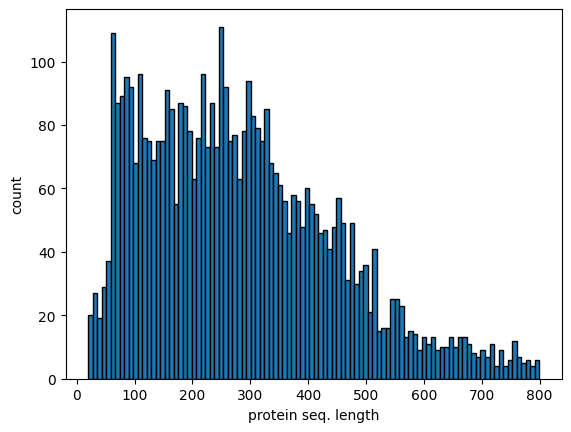

In [21]:
prot_sec_len = [len(s) for s in prot2sec.values()]
plt.hist(prot_sec_len, bins=100, edgecolor='k')
plt.xlabel('protein seq. length')
plt.ylabel('count')
# plt.savefig('seq_len.png')
plt.show()

In [22]:
print(prot_sec_len)

[158, 236, 252, 341, 149, 277, 346, 394, 337, 127, 79, 200, 530, 372, 480, 447, 91, 130, 358, 129, 503, 214, 203, 474, 187, 513, 529, 343, 229, 359, 199, 467, 296, 107, 310, 342, 763, 83, 62, 590, 382, 241, 798, 57, 258, 74, 266, 224, 125, 68, 230, 425, 340, 109, 140, 258, 141, 342, 370, 364, 108, 438, 238, 704, 313, 523, 310, 102, 182, 318, 648, 162, 489, 252, 89, 187, 473, 378, 304, 153, 76, 122, 201, 151, 549, 196, 119, 26, 127, 638, 194, 420, 88, 414, 328, 58, 263, 446, 309, 239, 342, 456, 63, 81, 149, 240, 70, 400, 87, 321, 220, 516, 70, 359, 306, 748, 316, 306, 185, 382, 82, 328, 257, 129, 313, 432, 515, 84, 281, 150, 384, 249, 299, 205, 156, 21, 350, 219, 294, 181, 339, 109, 673, 90, 166, 444, 323, 127, 246, 187, 450, 229, 773, 155, 99, 93, 391, 222, 477, 83, 147, 302, 99, 200, 449, 283, 415, 394, 210, 438, 152, 81, 540, 319, 369, 288, 328, 246, 317, 225, 284, 248, 360, 336, 208, 267, 42, 130, 69, 79, 285, 512, 176, 209, 423, 274, 171, 88, 457, 191, 490, 317, 427, 142, 472, 326,

In [23]:
def count_consecutive(s):
    consecutive_counts = {'E': [], 'H': [], '-': []}
    last_char = None
            
    streak = ''
    for char in s:
        if char == last_char:
            streak += char
            last_char = char
        else:
            if last_char != None:
                streak += last_char
                consecutive_counts[last_char].append(streak)
                streak = ''
                last_char = char
            else:
                last_char = char
    
    return consecutive_counts

# TEST: List of strings
strings = [
    '-------EEEEEE----HHHHHHHHHHHHHHHHHHHH-----HHHHHHHHH-------HHHHHHHHHHHH----------',
    '------EEEEEEE-----EHHHHHHH--------------------EEEHHHHHH-HHHHHH----EEEEEEEEE-----',
    '--EEEEEEEEE--------EEEEEEHHHHH--------HHHHHHHHHHHHHHHHH-EEEEEE-------EEEEEEEH---'
]

# Count consecutive occurrences of 'E' and 'H' for each string
for s in strings:
    counts = count_consecutive(s)
    print(f"E:{counts['E']}, H:{counts['H']}, -:{counts['-']}")

E:['EEEEEE'], H:['HHHHHHHHHHHHHHHHHHHH', 'HHHHHHHHH', 'HHHHHHHHHHHH'], -:['-------', '----', '-----', '-------']
E:['EEEEEEE', 'E', 'EEE', 'EEEEEEEEE'], H:['HHHHHHH', 'HHHHHH', 'HHHHHH'], -:['------', '-----', '--------------------', '-', '----']
E:['EEEEEEEEE', 'EEEEEE', 'EEEEEE', 'EEEEEEE'], H:['HHHHH', 'HHHHHHHHHHHHHHHHH', 'H'], -:['--', '--------', '--------', '-', '-------']


In [24]:
e_len = []
h_len = []
dash_len = []

for seq in prot2sec.values():
    counts = count_consecutive(seq)
    print(f"E:{[len(i) for i in counts['E']]}, H:{[len(i) for i in counts['H']]}, -:{[len(i) for i in counts['-']]}")
    e_len.extend([len(i) for i in counts['E']])
    h_len.extend([len(i) for i in counts['H']])
    dash_len.extend([len(i) for i in counts['-']])

E:[3, 13, 8, 4, 6, 11], H:[35, 22, 9], -:[6, 6, 3, 8, 5, 9, 6, 3]
E:[2, 6, 8, 12, 4, 4, 7, 9, 6, 5, 6, 5, 9, 3, 4, 5, 1], H:[22], -:[3, 3, 2, 4, 4, 15, 3, 4, 8, 16, 4, 5, 3, 3, 11, 4, 8, 4]
E:[7, 3, 2], H:[17, 17, 17, 9, 45, 11, 17, 14, 14], -:[2, 22, 8, 5, 5, 4, 2, 5, 4, 4, 14]
E:[5, 8, 5], H:[12, 20, 7, 37, 61, 9, 36, 45], -:[5, 2, 7, 3, 18, 4, 32, 5, 1, 4, 9]
E:[4, 5, 8, 3, 3, 10, 9], H:[1, 34, 10], -:[1, 11, 16, 1, 3, 5, 3, 9, 7, 4]
E:[6, 9, 8, 6, 4, 1, 3, 3, 5, 6], H:[6, 15, 13, 5, 6, 11, 17], -:[2, 4, 5, 9, 15, 4, 8, 29, 8, 2, 7, 13, 15, 6, 11, 4, 7]
E:[8, 1, 6, 2, 3, 4, 5], H:[9, 14, 13, 12, 10, 14, 13, 14, 10, 11, 13], -:[8, 3, 4, 15, 15, 4, 9, 5, 7, 7, 14, 6, 5, 5, 18, 16, 18, 13]
E:[], H:[21, 7, 26, 52, 29, 21, 9, 29, 25, 23, 29, 28, 27], -:[2, 2, 4, 4, 6, 3, 10, 4, 5, 4, 1, 5, 7]
E:[4, 6, 6, 5, 7, 2, 6, 3, 7, 6, 3], H:[11, 10, 21, 17, 9, 14, 13, 9, 6, 8, 14], -:[2, 5, 3, 14, 3, 4, 9, 4, 2, 22, 4, 12, 5, 5, 7, 5, 5, 5, 14, 7, 7]
E:[], H:[13, 5, 16, 11, 8, 21, 4], -:[3, 11, 14

In [25]:
print(h_len)

[35, 22, 9, 22, 17, 17, 17, 9, 45, 11, 17, 14, 14, 12, 20, 7, 37, 61, 9, 36, 45, 1, 34, 10, 6, 15, 13, 5, 6, 11, 17, 9, 14, 13, 12, 10, 14, 13, 14, 10, 11, 13, 21, 7, 26, 52, 29, 21, 9, 29, 25, 23, 29, 28, 27, 11, 10, 21, 17, 9, 14, 13, 9, 6, 8, 14, 13, 5, 16, 11, 8, 21, 4, 6, 8, 25, 10, 16, 12, 10, 7, 9, 26, 15, 12, 5, 12, 12, 9, 59, 9, 8, 10, 4, 14, 12, 8, 8, 13, 21, 14, 2, 7, 13, 6, 16, 16, 10, 17, 12, 12, 13, 18, 6, 11, 19, 4, 15, 9, 10, 16, 6, 5, 10, 12, 13, 9, 5, 15, 9, 13, 9, 12, 12, 15, 17, 15, 15, 2, 6, 20, 6, 8, 15, 16, 17, 6, 7, 13, 9, 8, 10, 11, 12, 28, 11, 30, 27, 19, 18, 16, 23, 14, 6, 14, 13, 8, 14, 10, 15, 6, 22, 55, 35, 27, 9, 12, 19, 12, 10, 18, 9, 8, 10, 14, 15, 17, 5, 18, 25, 15, 9, 7, 11, 22, 13, 10, 22, 13, 14, 10, 8, 9, 10, 14, 6, 12, 10, 20, 14, 14, 7, 1, 27, 16, 12, 15, 9, 17, 9, 8, 15, 14, 7, 11, 17, 10, 6, 10, 10, 9, 15, 15, 5, 10, 17, 14, 6, 8, 29, 24, 42, 26, 36, 13, 20, 13, 10, 10, 7, 14, 12, 8, 13, 2, 10, 21, 11, 12, 15, 19, 8, 10, 9, 33, 6, 19, 3, 25, 4,

In [26]:
print(len(dash_len), len(e_len), len(h_len))

72260 36172 38713


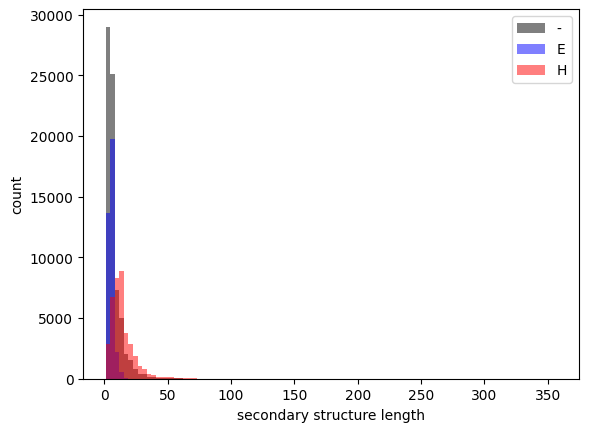

In [29]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(dash_len), min(e_len), min(h_len))
max_val = max(max(dash_len), max(e_len), max(h_len))
bins = np.linspace(min_val, max_val, 100)

plt.hist(dash_len, bins=bins, color='k', label='-', alpha=0.5)  # '-'
plt.hist(e_len, bins=bins, color='b', label='E', alpha=0.5)  # beta-sheet
plt.hist(h_len, bins=bins, color='r', label='H', alpha=0.5)  # alpha-helix

# Set x-axis range
# plt.xlim(0, 80)

plt.xlabel('secondary structure length')
plt.ylabel('count')
plt.legend()
# plt.savefig('sec_len_full.png')
plt.show()

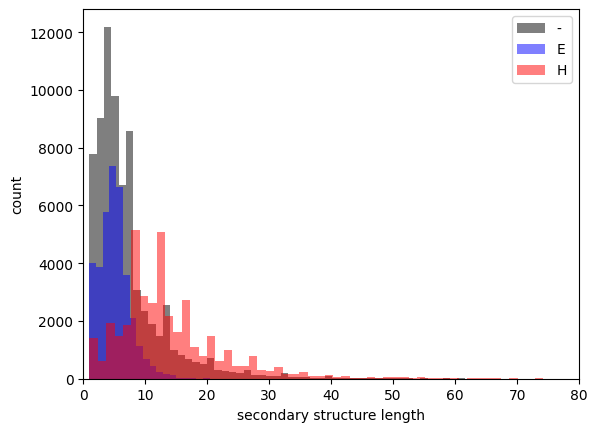

In [30]:
# zoom into xlim(0, 80)

# arbitrary bins... 
plt.hist(dash_len, bins=300, color='k', label='-', alpha=0.5)  # '-'
plt.hist(e_len, bins=25, color='b', label='E', alpha=0.5)  # beta-sheet
plt.hist(h_len, bins=200, color='r', label='H', alpha=0.5)  # alpha-helix

# Set x-axis range
plt.xlim(0, 80)

plt.xlabel('secondary structure length')
plt.ylabel('count')
plt.legend()
# plt.savefig('sec_len_zoom.png')
plt.show()

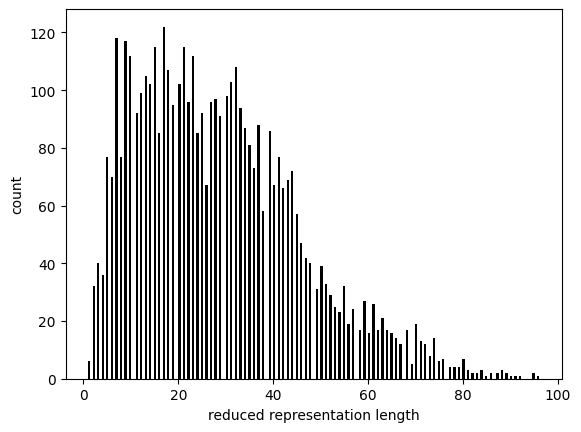

In [31]:
result_len = [len(v) for v in prot2sec_reduced.values()]
plt.hist(result_len, bins=200, color='k')
plt.xlabel('reduced representation length')
plt.ylabel('count')
# plt.savefig('reduced_len.png')
plt.show()

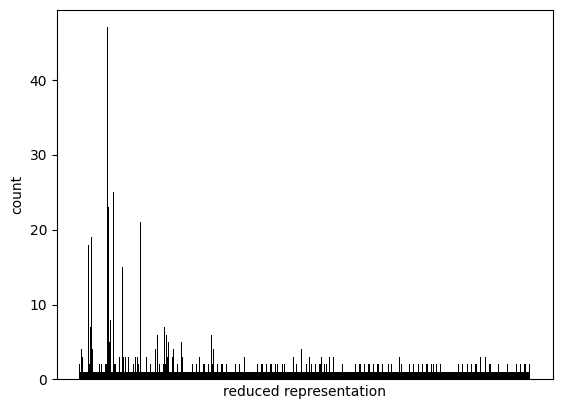

In [32]:
from collections import Counter

result_seq = list(prot2sec_reduced.values())
plt.hist(result_seq, bins=3000, color='k')
    
plt.xticks([])
plt.xlabel('reduced representation')
plt.ylabel('count')
# plt.savefig('reduced_histo.png')
plt.show()

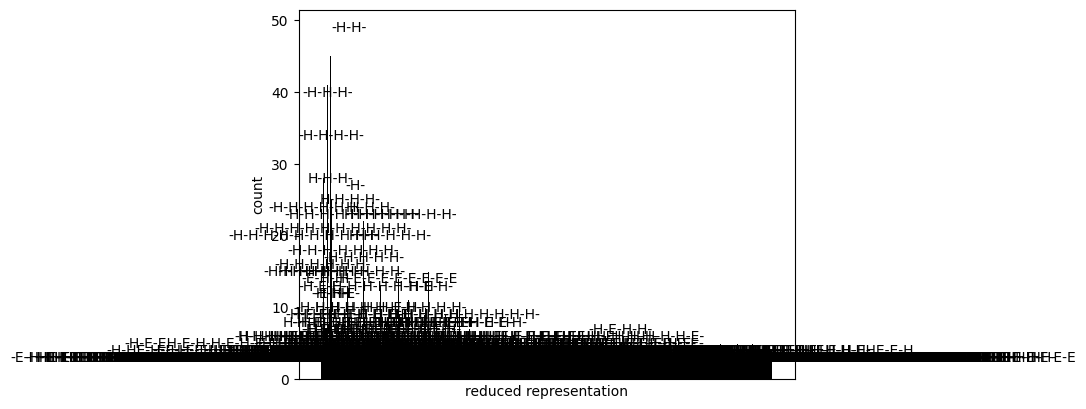

In [33]:
plt.hist(result_seq, bins=1000, color='k')

category_counts = Counter(result_seq)
for category, count in category_counts.items():
    plt.annotate(category, xy=(category, count), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom')
    
plt.xticks([])
plt.xlabel('reduced representation')
plt.ylabel('count')
plt.show()

In [34]:
print(category_counts)

Counter({'-H-H-': 47, '-H-H-H-': 38, '-H-H-H-H-': 32, 'H-H-H-': 26, '-H-': 25, 'H-H-H-H-': 23, '-H-H-H-H-H-H-H-H-': 22, 'H-': 22, '-H-H-H-H-H-H-H-H-H-H-H-': 21, 'H-H-H-H-H-': 21, '-H-H-H-H-H-H-H-H-H-H-': 19, '-H-H-H-H-H-H-H-H-H-H-H-H-H-': 18, 'H-H-': 18, '-H-H-H-H-H-H-H-': 16, '-H-H-H-H-H-': 15, '-H-H-H-H-H-H-': 14, '-H-H-H': 13, 'H-H-H-H-H-H-': 13, '-H-H-H-H-H-H-H-H-H-': 13, '-E-H-H-': 12, 'H-E-E-E-E-E-E-E-E': 12, '-H-E-E-': 11, '-H-H-H-H-H-H-H': 11, '-H-E-H-': 11, '-E-H-': 10, '-H-H-E-': 10, '-H': 10, '-H-H-H-H': 8, '-H-H-E-H-': 8, 'H-H-H-H-H-H-H-H-H-H-': 8, '-H-H': 7, '-H-E-E-E-E-E-E-E-E': 7, '-E-': 7, '-H-H-H-H-H-H-H-H': 7, 'H-H-H-H-H': 7, '-H-H-H-H-H-H-H-H-H-H-H-H-': 7, '-H-H-E-H-H-': 6, 'H-H-H-H-H-H-H-': 6, '-E-E-E-E-E': 6, '-H-E-': 6, 'H-E-': 6, '-E-E-H-H-': 6, '-H-H-H-H-H-H-H-H-H-H-H-H-H-H-': 6, 'H-H-H-H': 6, '-H-H-E-E-': 6, '-H-E-E-E-E-': 6, '-E-E-H-': 6, '-H-E-H-E-E-H-E-E-H-': 6, 'H-E-H-': 5, '-H-E-H-E-E': 5, 'H': 5, '-E-E-E-E-E-E-E-': 5, '-H-H-H-H-E-': 5, 'H-H-H-H-H-H-H-H-H-

In [35]:
len(prot2sec)

4557

In [36]:
len(category_counts)

3553

In [37]:
from collections import defaultdict

tally = defaultdict(int)
for num in category_counts.values():
    tally[num] += 1
tally_dict = dict(tally)
ordered_tally_dict = dict(sorted(tally_dict.items(), reverse=True))

In [38]:
ordered_tally_dict

{47: 1,
 38: 1,
 32: 1,
 26: 1,
 25: 1,
 23: 1,
 22: 2,
 21: 2,
 19: 1,
 18: 2,
 16: 1,
 15: 1,
 14: 1,
 13: 3,
 12: 2,
 11: 3,
 10: 3,
 8: 3,
 7: 6,
 6: 12,
 5: 9,
 4: 22,
 3: 49,
 2: 211,
 1: 3214}

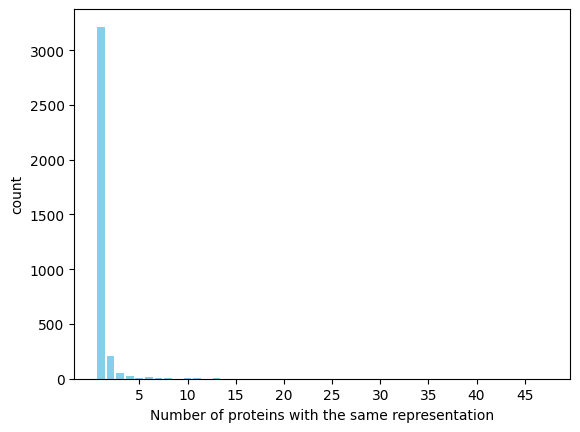

In [40]:
values = list(ordered_tally_dict.keys())
frequencies = list(ordered_tally_dict.values())

plt.bar(values, frequencies, color='skyblue') 
plt.xlabel('Number of proteins with the same representation')
plt.ylabel('count')
plt.xticks([5, 10, 15, 20, 25, 30, 35, 40, 45])
# plt.savefig('last.png')
plt.show()

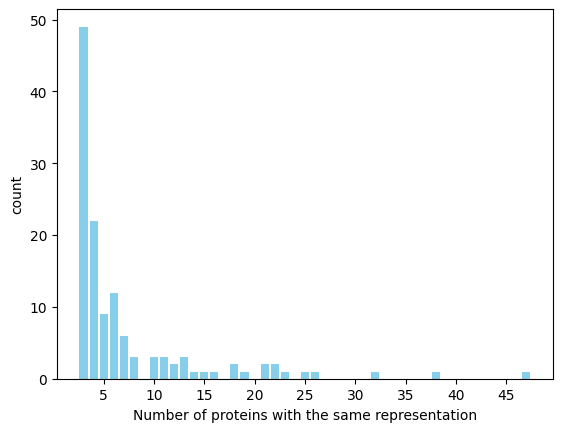

In [41]:
# Extract values and frequencies
values = list(ordered_tally_dict.keys())[:-2]
frequencies = list(ordered_tally_dict.values())[:-2]

plt.bar(values, frequencies, color='skyblue') 
plt.xlabel('Number of proteins with the same representation')
plt.ylabel('count')
plt.xticks([5, 10, 15, 20, 25, 30, 35, 40, 45])
# plt.savefig('last_zoom.png')
plt.show()

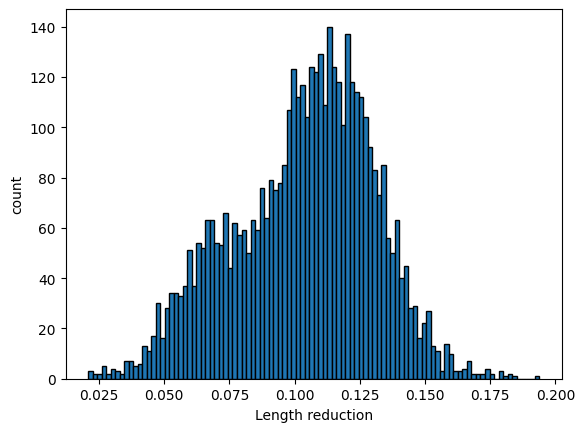

In [42]:
reductionRate = []
for key in prot2sec.keys():
    reductionRate.append(len(prot2sec_reduced[key]) / len(prot2sec[key]))

plt.hist(reductionRate, bins=100, edgecolor='k')
plt.xlabel('Length reduction')
plt.ylabel('count')
# plt.savefig('reductionRate.png')
plt.show()

In [43]:
prot2sec_reduced

{'AYO74062.1': '-H-H-E-E-E-EH-E-E',
 'AYO72500.1': '-H-E-E-E-E-E-E-E-E-E-E-E-E-E-E-E-',
 'AYO74375.1': 'H-H-H-E-E-H-H-H-H-H-',
 'AYO75144.1': '-H-E-E-H-E-H-H-H-H-',
 'AYO72982.1': 'E-E-H-E-E-H-E-E-E',
 'AYO72435.1': 'E-E-E-E-H-E-H-EH-E-H-H-E-H-E-H-',
 'AYO72090.1': '-H-H-E-H-E-H-H-E-H-E-H-E-H-H-H-H-',
 'AYO75321.1': 'H-H-H-H-H-H-H-H-H-H-H-',
 'AYO75312.1': 'E-H-E-E-H-E-H-E-H-E-H-E-EH-E-H-E-H-H-H-H-',
 'AYO71735.1': '-H-H-H-H-H-H-',
 'AYO72648.1': '-H-E-E-',
 'AYO75076.1': 'H-H-E-H-H-H-E-H-E-E-',
 'AYO72046.1': 'E-E-H-E-E-H-H-H-H-H-H-EHE-E-H-E-E-E-H-E-E-H-H-H-H-E-H-EHE-E-H-',
 'AYO71842.1': 'EH-E-H-E-H-H-E-H-E-E-E-E-H-E-H-E-E-H-',
 'AYO71075.1': '-E-H-E-H-E-E-E-E-E-E-E-H-E-H-E-H-E-H-EH-H-H-H-E-H-EH-E-H-E-E',
 'AYO71974.1': '-H-H-H-E-H-E-H-E-H-E-HE-H-H-H-EH-H-H-H-H-H-H-H-E-H-',
 'AYO74941.1': 'H-E-H-H-',
 'AYO72835.1': '-H-H-E-E-E-E-',
 'AYO71147.1': 'E-E-E-E-E-E-E-H-H-EH-E-H-E-H-E-H-E-E-H-EH-E-',
 'AYO75315.1': '-H-H-H',
 'AYO72923.1': 'E-E-H-E-E-H-H-E-H-H-EH-E-E-E-H-E-E-E-H-EHE-E-H-H-E

In [56]:
def dict2csv2(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict2(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        lines = csv_file.readlines()
        for line in lines:
            # Create a dictionary
            result_dict[line.split(',')[0]] = line.split(',')[1].strip()
    return result_dict

In [57]:
dict2csv2(prot2sec_reduced, 'prot2sec_reduced.csv')

In [58]:
d = csv2dict2('prot2sec_reduced.csv')
d

{'AYO74062.1': '-H-H-E-E-E-EH-E-E',
 'AYO72500.1': '-H-E-E-E-E-E-E-E-E-E-E-E-E-E-E-E-',
 'AYO74375.1': 'H-H-H-E-E-H-H-H-H-H-',
 'AYO75144.1': '-H-E-E-H-E-H-H-H-H-',
 'AYO72982.1': 'E-E-H-E-E-H-E-E-E',
 'AYO72435.1': 'E-E-E-E-H-E-H-EH-E-H-H-E-H-E-H-',
 'AYO72090.1': '-H-H-E-H-E-H-H-E-H-E-H-E-H-H-H-H-',
 'AYO75321.1': 'H-H-H-H-H-H-H-H-H-H-H-',
 'AYO75312.1': 'E-H-E-E-H-E-H-E-H-E-H-E-EH-E-H-E-H-H-H-H-',
 'AYO71735.1': '-H-H-H-H-H-H-',
 'AYO72648.1': '-H-E-E-',
 'AYO75076.1': 'H-H-E-H-H-H-E-H-E-E-',
 'AYO72046.1': 'E-E-H-E-E-H-H-H-H-H-H-EHE-E-H-E-E-E-H-E-E-H-H-H-H-E-H-EHE-E-H-',
 'AYO71842.1': 'EH-E-H-E-H-H-E-H-E-E-E-E-H-E-H-E-E-H-',
 'AYO71075.1': '-E-H-E-H-E-E-E-E-E-E-E-H-E-H-E-H-E-H-EH-H-H-H-E-H-EH-E-H-E-E',
 'AYO71974.1': '-H-H-H-E-H-E-H-E-H-E-HE-H-H-H-EH-H-H-H-H-H-H-H-E-H-',
 'AYO74941.1': 'H-E-H-H-',
 'AYO72835.1': '-H-H-E-E-E-E-',
 'AYO71147.1': 'E-E-E-E-E-E-E-H-H-EH-E-H-E-H-E-H-E-E-H-EH-E-',
 'AYO75315.1': '-H-H-H',
 'AYO72923.1': 'E-E-H-E-E-H-H-E-H-H-EH-E-E-E-H-E-E-E-H-EHE-E-H-H-E